# Part 2A-i: Custom Learning Rate Scheduler


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_test = X_train.astype("float32") / 255.0, X_test.astype("float32") / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()

X_flat_tr = X_train.reshape(len(X_train), -1)
X_flat_te = X_test.reshape(len(X_test), -1)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


## TensorFlow: Custom OneCycleScheduler

The 1cycle policy ramps LR up from a low value to `max_lr`, then anneals it back down. This was proposed by Leslie Smith and can improve convergence speed and final performance.


In [2]:
# Custom OneCycle Scheduler as Keras Callback
class OneCycleScheduler(keras.callbacks.Callback):
    """
    1Cycle Learning Rate Policy.
    Phase 1: LR ramps up from max_lr/div_factor to max_lr
    Phase 2: LR anneals down from max_lr to max_lr/final_div using cosine annealing
    """
    def __init__(self, max_lr, steps_per_epoch, epochs, pct_start=0.3, div_factor=25.0, final_div=1e4):
        super().__init__()
        self.max_lr = max_lr
        self.total_steps = steps_per_epoch * epochs
        self.pct_start = pct_start
        self.div_factor = div_factor
        self.final_div = final_div
        self.step_count = 0
        self.history = []

    def _compute_lr(self):
        progress = self.step_count / self.total_steps

        if progress < self.pct_start:
            # Phase 1: linear warmup
            pct = progress / self.pct_start
            lr = (self.max_lr / self.div_factor) + (self.max_lr - self.max_lr / self.div_factor) * pct
        else:
            # Phase 2: cosine annealing
            pct = (progress - self.pct_start) / (1 - self.pct_start)
            lr = (self.max_lr / self.final_div) + \
                 (self.max_lr - self.max_lr / self.final_div) * 0.5 * (1 + np.cos(np.pi * pct))

        return float(lr)

    def on_train_batch_begin(self, batch, logs=None):
        lr = self._compute_lr()

        # Fixed: avoid keras.backend.set_value(...) issue
        if hasattr(self.model.optimizer.learning_rate, "assign"):
            self.model.optimizer.learning_rate.assign(lr)
        else:
            self.model.optimizer.learning_rate = lr

        self.history.append(lr)
        self.step_count += 1


# Exponential decay scheduler for comparison
class ExponentialDecayScheduler(keras.callbacks.Callback):
    def __init__(self, initial_lr=1e-3, decay_rate=0.95):
        super().__init__()
        self.initial_lr = initial_lr
        self.decay_rate = decay_rate
        self.history = []

    def on_epoch_begin(self, epoch, logs=None):
        lr = float(self.initial_lr * (self.decay_rate ** epoch))

        # Fixed here too
        if hasattr(self.model.optimizer.learning_rate, "assign"):
            self.model.optimizer.learning_rate.assign(lr)
        else:
            self.model.optimizer.learning_rate = lr

        self.history.append(lr)


In [3]:
# Train with OneCycle
batch_size = 256
epochs = 30
steps = int(len(X_flat_tr) * 0.8) // batch_size   # because validation_split=0.2

onecycle = OneCycleScheduler(max_lr=0.01, steps_per_epoch=steps, epochs=epochs)

model_1c = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_1c.compile(
    optimizer=keras.optimizers.SGD(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

h_1c = model_1c.fit(
    X_flat_tr, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[onecycle],
    verbose=0
)

# Train with ExponentialDecay
exp_decay = ExponentialDecayScheduler(initial_lr=1e-3, decay_rate=0.95)

model_exp = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_exp.compile(
    optimizer=keras.optimizers.SGD(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

h_exp = model_exp.fit(
    X_flat_tr, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[exp_decay],
    verbose=0
)

# Constant LR baseline
model_const = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_const.compile(
    optimizer=keras.optimizers.SGD(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

h_const = model_const.fit(
    X_flat_tr, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=0
)


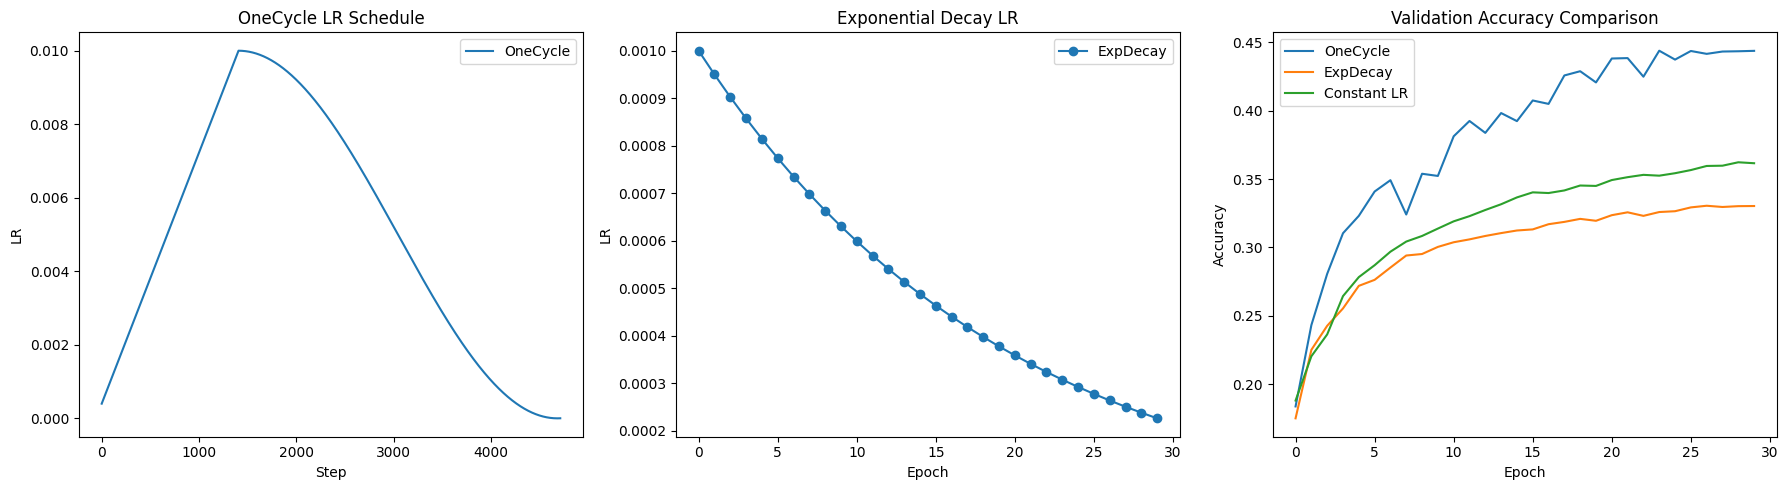

In [4]:
# Visualize LR schedules and training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(onecycle.history, label='OneCycle')
axes[0].set_title('OneCycle LR Schedule')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('LR')
axes[0].legend()

axes[1].plot(exp_decay.history, 'o-', label='ExpDecay')
axes[1].set_title('Exponential Decay LR')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('LR')
axes[1].legend()

axes[2].plot(h_1c.history['val_accuracy'], label='OneCycle')
axes[2].plot(h_exp.history['val_accuracy'], label='ExpDecay')
axes[2].plot(h_const.history['val_accuracy'], label='Constant LR')
axes[2].set_title('Validation Accuracy Comparison')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.show()


## PyTorch: OneCycleLR (built-in) and Custom


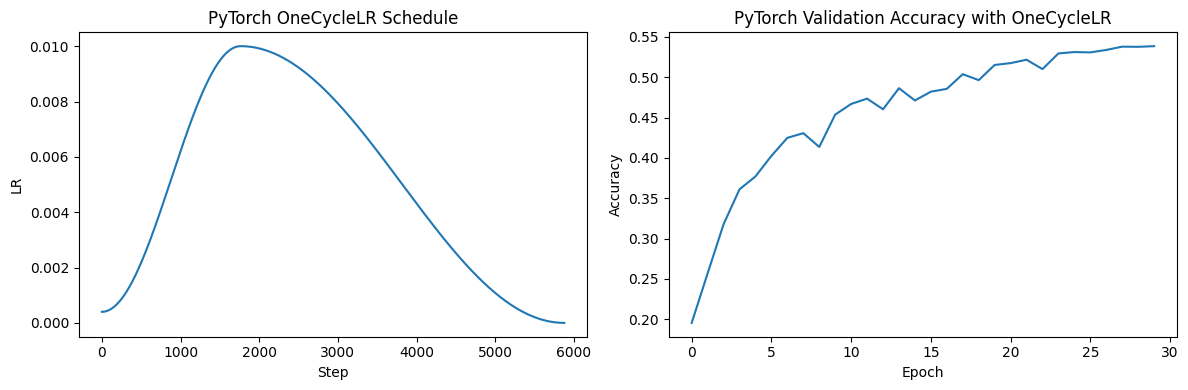

Final Test Acc: 0.5385


In [5]:
# PyTorch OneCycleLR
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_flat_tr), torch.LongTensor(y_train)),
    batch_size=256,
    shuffle=True
)

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3072, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

model_pt = SimpleNet().to(device)
opt = optim.SGD(model_pt.parameters(), lr=0.01, momentum=0.9)
scheduler = optim.lr_scheduler.OneCycleLR(
    opt,
    max_lr=0.01,
    steps_per_epoch=len(loader),
    epochs=30
)
crit = nn.CrossEntropyLoss()

lr_history = []
val_accs = []

for ep in range(30):
    model_pt.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        opt.zero_grad()
        loss = crit(model_pt(xb), yb)
        loss.backward()
        opt.step()

        lr_history.append(scheduler.get_last_lr()[0])
        scheduler.step()

    model_pt.eval()
    with torch.no_grad():
        xt = torch.FloatTensor(X_flat_te).to(device)
        yt = torch.LongTensor(y_test).to(device)
        preds = model_pt(xt).argmax(1)
        acc = (preds == yt).float().mean().item()
        val_accs.append(acc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lr_history)
axes[0].set_title('PyTorch OneCycleLR Schedule')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('LR')

axes[1].plot(val_accs)
axes[1].set_title('PyTorch Validation Accuracy with OneCycleLR')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

print(f'Final Test Acc: {val_accs[-1]:.4f}')


## Key Takeaways

- **OneCycle** increases the learning rate first, then decreases it with cosine annealing.
- **Exponential Decay** reduces the LR smoothly after each epoch.
- **Constant LR** is the simplest baseline, but usually less adaptive.
- In TensorFlow/Keras, updating the optimizer LR should use `.assign(...)` when available instead of `keras.backend.set_value(...)` to avoid compatibility issues.
